In [4]:
import pandas as pd

df = pd.read_csv("../data/product_info 2.csv")
df.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


## Data Understanding

The dataset was loaded using Pandas. I first checked the structure of the dataset, including the number of rows, columns, data types, and missing values. This step helps identify which features may be useful for product feedback analysis.


Although the dataset contains 27 columns, only a subset of relevant features was selected for initial exploration, such as product name, brand, rating, reviews, price, and category.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   str    
 1   product_name        8494 non-null   str    
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   str    
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   str    
 8   variation_type      7050 non-null   str    
 9   variation_value     6896 non-null   str    
 10  variation_desc      1250 non-null   str    
 11  ingredients         7549 non-null   str    
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new              

In [8]:
df.shape

(8494, 27)

In [9]:
df[['product_name', 'brand_name', 'rating', 'reviews', 'price_usd', 'primary_category']].head()

,product_name,brand_name,rating,reviews,price_usd,primary_category
0,Fragrance Discovery Set,19-69,3.6364,11.0,35.0,Fragrance
1,La Habana Eau de Parfum,19-69,4.1538,13.0,195.0,Fragrance
2,Rainbow Bar Eau de Parfum,19-69,4.2500,16.0,195.0,Fragrance
3,Kasbah Eau de Parfum,19-69,4.4762,21.0,195.0,Fragrance
4,Purple Haze Eau de Parfum,19-69,3.2308,13.0,195.0,Fragrance


In [4]:
df.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'variation_type', 'variation_value',
       'variation_desc', 'ingredients', 'price_usd', 'value_price_usd',
       'sale_price_usd', 'limited_edition', 'new', 'online_only',
       'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count',
       'child_max_price', 'child_min_price'],
      dtype='str')

In [5]:
df.describe()

,brand_id,loves_count,rating,reviews,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,child_count,child_max_price,child_min_price
count,8494.000000,8.494000e+03,8216.000000,8216.000000,8494.000000,451.000000,270.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,2754.000000,2754.000000
mean,5422.440546,2.917957e+04,4.194513,448.545521,51.655595,91.168537,20.207889,0.070285,0.071698,0.219096,0.073699,0.279374,1.631622,53.792023,39.665802
std,1709.595957,6.609212e+04,0.516694,1101.982529,53.669234,79.195631,24.327352,0.255642,0.258002,0.413658,0.261296,0.448718,5.379470,58.765894,38.685720
min,1063.000000,0.000000e+00,1.000000,1.000000,3.000000,0.000000,1.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000
25%,5333.000000,3.758000e+03,3.981725,26.000000,25.000000,45.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,19.000000
50%,6157.500000,9.880000e+03,4.289350,122.000000,35.000000,67.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,28.000000
75%,6328.000000,2.684125e+04,4.530525,418.000000,58.000000,108.500000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,59.000000,42.000000
max,8020.000000,1.401068e+06,5.000000,21281.000000,1900.000000,617.000000,320.000000,1.000000,1.000000,1.000000,1.000000,1.000000,105.000000,570.000000,400.000000


In [6]:
df.isnull().sum()

product_id               0
product_name             0
brand_id                 0
brand_name               0
loves_count              0
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
price_usd                0
value_price_usd       8043
sale_price_usd        8224
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
tertiary_category      990
child_count              0
child_max_price       5740
child_min_price       5740
dtype: int64

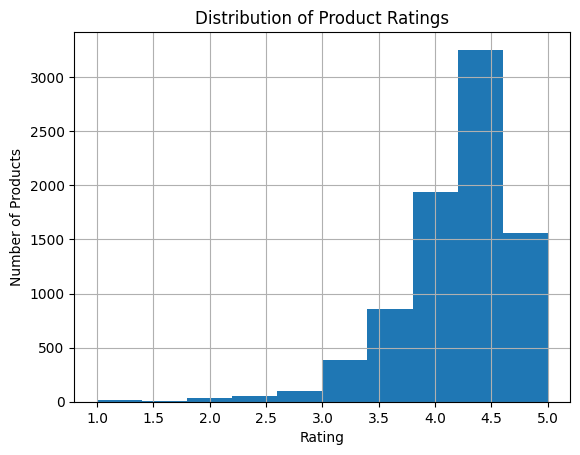

In [11]:
import matplotlib.pyplot as plt

plt.figure()
df['rating'].hist()
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Products')
plt.show()

### Rating Distribution Analysis

The histogram shows that most products have ratings between 4.0 and 5.0, indicating that the majority of products are highly rated by customers.

There are very few products with low ratings (below 3.0), which suggests that the dataset is skewed toward positive reviews. This may indicate overall customer satisfaction, but it can also reflect bias, where users are more likely to leave reviews for products they like.

This insight is important because it shows that sentiment analysis may also be biased toward positive sentiment, and special attention should be given to detecting negative feedback.

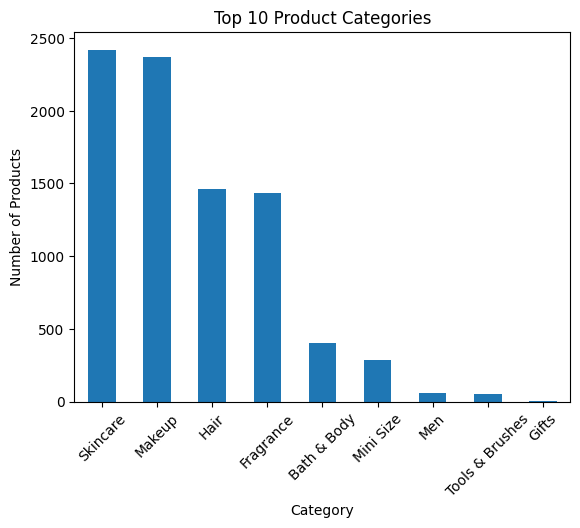

In [12]:
import matplotlib.pyplot as plt

df['primary_category'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

### Product Category Distribution Analysis

The bar chart shows the distribution of products across different categories. Skincare and Makeup are the most dominant categories, each containing a significantly higher number of products compared to others.

Hair and Fragrance also represent a large portion of the dataset, while categories such as Men, Gifts, and Brushes have relatively fewer products.

This distribution indicates that the dataset is not balanced across categories. As a result, any further analysis, including sentiment analysis, may be influenced more heavily by the dominant categories. This is important to consider when generating insights for product managers.


In [6]:
def label_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating >= 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(label_sentiment)

df[["product_name", "rating", "sentiment"]].head()

,product_name,rating,sentiment
0,Fragrance Discovery Set,3.6364,Neutral
1,La Habana Eau de Parfum,4.1538,Positive
2,Rainbow Bar Eau de Parfum,4.2500,Positive
3,Kasbah Eau de Parfum,4.4762,Positive
4,Purple Haze Eau de Parfum,3.2308,Neutral


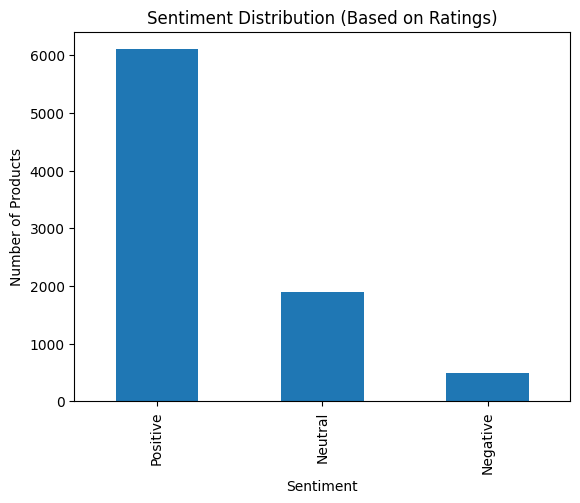

In [15]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution (Based on Ratings)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Products")
plt.show()

### Machine Learning Model

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [7]:
# Select features
X = df[['rating', 'reviews', 'price_usd']]

# Select target
y = df['sentiment']

In [12]:
# Prepare data for machine learning by removing missing values
df_ml = df[['rating', 'reviews', 'price_usd', 'sentiment']].dropna()

X = df_ml[['rating', 'reviews', 'price_usd']]
y = df_ml['sentiment']

In [13]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9860097323600974


In [32]:
# Show distribution of recommendations
df['recommendation'].value_counts()

recommendation
High performance: consider promoting this product and increasing visibility      3620
Stable product: maintain current strategy                                        2761
Moderate performance: monitor feedback and identify improvement opportunities    1900
Low performance: investigate potential issues and customer dissatisfaction        213
Name: count, dtype: int64

In [29]:
# Display random sample of products with recommendations
df[['product_name','rating','reviews','recommendation']].sample(10, random_state=42)

,product_name,rating,reviews,recommendation
8220,"Hydrating Recovery Shampoo for Dry, Damaged & ...",4.1830,153.0,High performance: consider promoting this prod...
4552,Aglow Golden Priming Oil,4.6207,58.0,Stable product: maintain current strategy
1535,Superdefense SPF 25 Fatigue + 1st Signs of Age...,3.8824,17.0,Moderate performance: monitor feedback and ide...
4228,Tinted Face Oil Comfy Skin Tint,3.6687,1781.0,Moderate performance: monitor feedback and ide...
5623,Cheek Clapper 3D Blush Trio Palette,4.7403,335.0,High performance: consider promoting this prod...
4584,Triple Bond Complex Leave-in Hair Treatment,4.3859,622.0,High performance: consider promoting this prod...
3792,Pro-Retinol Megamoisture Face Cream,4.7518,278.0,High performance: consider promoting this prod...
7319,SinglePass Curl ¾” Professional Curling Iron,4.9216,51.0,Stable product: maintain current strategy
5254,Audacious Lipstick,4.6191,2032.0,High performance: consider promoting this prod...
3661,Double Header Shampoo + Conditioner,4.1875,16.0,Stable product: maintain current strategy


In [30]:
# Identify low-performing products for business action
df[df['recommendation'].str.contains("Low performance")][
    ['product_name','rating','reviews','recommendation']
].head(10)

,product_name,rating,reviews,recommendation
45,Luce di Colonia Diffuser,2.6667,3.0,Low performance: investigate potential issues ...
87,Rose De Grasse Pour Filles Eau de Parfum,2.0000,1.0,Low performance: investigate potential issues ...
246,3D Volume and Thickening Conditioner,2.3333,9.0,Low performance: investigate potential issues ...
340,Laminated Look Brow Kit,1.1905,21.0,Low performance: investigate potential issues ...
406,Supreme Mauves Eyeshadow & Pressed Pigment Pal...,2.9333,45.0,Low performance: investigate potential issues ...
452,Mini MAXIMIST Phyto-Fiber Volumizing Mascara,1.8333,6.0,Low performance: investigate potential issues ...
481,GloPRO EYE MicroTip Attachment Head,2.5000,8.0,Low performance: investigate potential issues ...
506,Blendercleanser Liquid Charcoal Unscented Spon...,2.8333,12.0,Low performance: investigate potential issues ...
578,Hello Happy Velvet Powder Foundation,2.6667,96.0,Low performance: investigate potential issues ...
586,"Multitasking Cheek Brush for Powder Blush, Bro...",2.0000,2.0,Low performance: investigate potential issues ...


### Sentiment Analysis Based on Ratings

The sentiment distribution shows that the majority of products fall into the "Positive" category, with a significantly smaller portion classified as "Neutral" and very few as "Negative".

This indicates that most products in the dataset are well-rated by customers, suggesting overall satisfaction. However, the low number of negative ratings may also suggest a bias in user reviews, where customers are more likely to rate products they already like.

From a business perspective, this insight is important because it highlights that while most products perform well, the smaller group of neutral and negative products represents an opportunity for improvement and further investigation.


### Findings

The analysis shows that most products have high ratings, indicating overall positive customer satisfaction. However, the data is concentrated in a few categories, such as Skincare and Makeup, which may influence the results.

The sentiment analysis confirms that most products are classified as positive, with only a small number of neutral or negative cases. This suggests that while products generally perform well, there are still opportunities to improve lower-rated items.

Some missing values were also identified, which may limit deeper analysis. Overall, the findings highlight strong product performance but also point to areas where improvements can be made.